# Household Electric Power Consumption による電力需要予測デモ

UCI Machine Learning Repository の家庭電力使用データを使い、EDA、時刻・ラグ特徴量の作成、LightGBM による回帰を行います。


## 0. 概略

**特徴**

* 約207万レコード
* 約4年分
* 1分単位観測

実データに近いサイズで、大規模データであることに留意する必要がある

**課題**

翌1時間の電力消費量を予測する

目的変数: `Global_active_power`

説明変数:

* `日時`
* `電圧`
* `電流`
* `サブメータ`

---

## 1 準備

### 1.1 モジュール

UCI Machine Learning Repository からデータを取得するための `ucimlrepo` を Colab 環境にインストール


In [1]:
!pip install -U ucimlrepo -q

データ処理、可視化、UCI データ取得、LightGBM モデルに必要なモジュールを読み込む。

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from lightgbm import LGBMRegressor
from ucimlrepo import fetch_ucirepo

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 1.2 データ取得

`ucimlrepo` を使って UCI Machine Learning Repository から直接取得する。

Individual Household Electric Power Consumption データセットを直接取得し、メタデータを確認します。

In [3]:
# Household Electric Power Consumption: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption
electric_power = fetch_ucirepo(id=235)

electric_power.metadata

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 235,
 'name': 'Individual Household Electric Power Consumption',
 'repository_url': 'https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption',
 'data_url': 'https://archive.ics.uci.edu/static/public/235/data.csv',
 'abstract': 'Measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. Different electrical quantities and some sub-metering values are available.',
 'area': 'Physics and Chemistry',
 'tasks': ['Regression', 'Clustering'],
 'characteristics': ['Multivariate', 'Time-Series'],
 'num_instances': 2075259,
 'num_features': 9,
 'feature_types': ['Real'],
 'demographics': [],
 'target_col': None,
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2006,
 'last_updated': 'Fri Mar 08 2024',
 'dataset_doi': '10.24432/C58K54',
 'creators': ['Georges Hebrail', 'Alice Berard'],
 'intro_paper': None,
 'additional_info': {'s

**変数の意味を確認**

データセットに含まれる各変数の名前、役割、型、説明、単位、欠損値の有無を表として確認。

In [4]:
variable_cols = [
    "name",
    "role",
    "type",
    "description",
    "units",
    "missing_values",
]

variable_info = electric_power.variables[
    [col for col in variable_cols if col in electric_power.variables.columns]
]

display(variable_info)


,name,role,type,description,units,missing_values
0,Date,Feature,Date,None,None,no
1,Time,Feature,Categorical,None,None,no
2,Global_active_power,Feature,Continuous,None,None,no
3,Global_reactive_power,Feature,Continuous,None,None,no
4,Voltage,Feature,Continuous,None,None,no
5,Global_intensity,Feature,Continuous,None,None,no
6,Sub_metering_1,Feature,Continuous,None,None,no
7,Sub_metering_2,Feature,Continuous,None,None,no
8,Sub_metering_3,Feature,Continuous,None,None,no


**データ確認**

UCI から取得した元データを pandas の DataFrame として `df` にコピーし、行数・列数と先頭行を確認

In [5]:
df = electric_power.data.original.copy()

print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


### 1.3 前処理

**日時変換**

別々の列になっている日付 `Date` と時刻 `Time` を結合し、時系列処理に使える `datetime` 型の列を作成する。

In [6]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)


**数値変換**

このコードでは、電力消費量、電圧、電流、サブメータなどの列を数値型に変換する。  
変換できない値は欠損値として扱う。


In [7]:
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")



**欠損値確認**

このコードでは、数値変数に欠損値がどれだけ含まれているかを列ごとに確認する。

単純化のため、欠損値を含む行を削除する。


In [8]:
df[numeric_cols].isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [9]:
df = df.dropna()

print(df.shape)


(2049280, 10)



---

## 2. EDA

### 2.1 電力消費の分布

目的変数として使う `Global_active_power` の分布をヒストグラムで確認する。


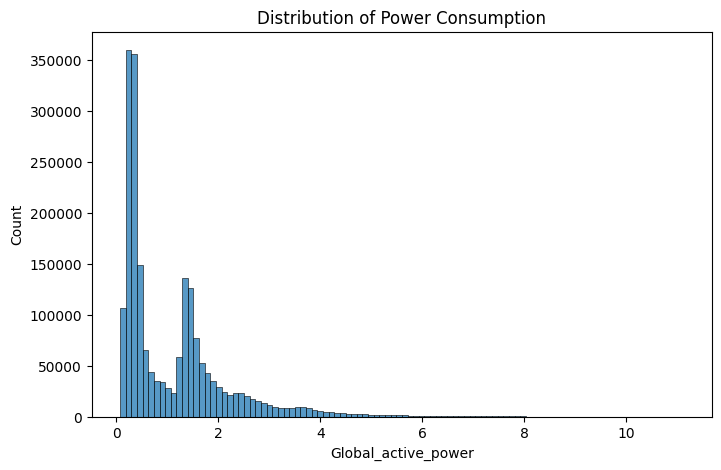

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Global_active_power"],
    bins=100
)

plt.title("Distribution of Power Consumption")
plt.show()

### 2.2 時系列推移

全部描くと重いので、100行に1行だけを取り出したサンプルデータを作成する。

電力消費量が時間とともにどう変化しているかを折れ線グラフで確認。

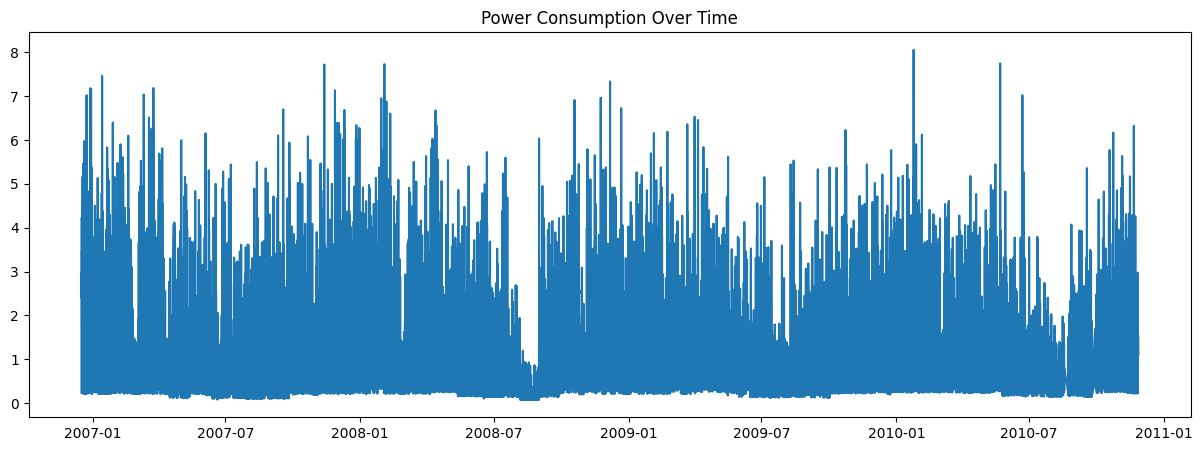

In [11]:
sample = df.iloc[::100]

plt.figure(figsize=(15,5))

plt.plot(
    sample["datetime"],
    sample["Global_active_power"]
)

plt.title("Power Consumption Over Time")
plt.show()


### 2.3 時間帯別平均

日時から時間帯 `hour` を取り出し、時間帯ごとの平均電力消費量を計算。

In [12]:
df["hour"] = df["datetime"].dt.hour

hourly = (
    df.groupby("hour")
      ["Global_active_power"]
      .mean()
)


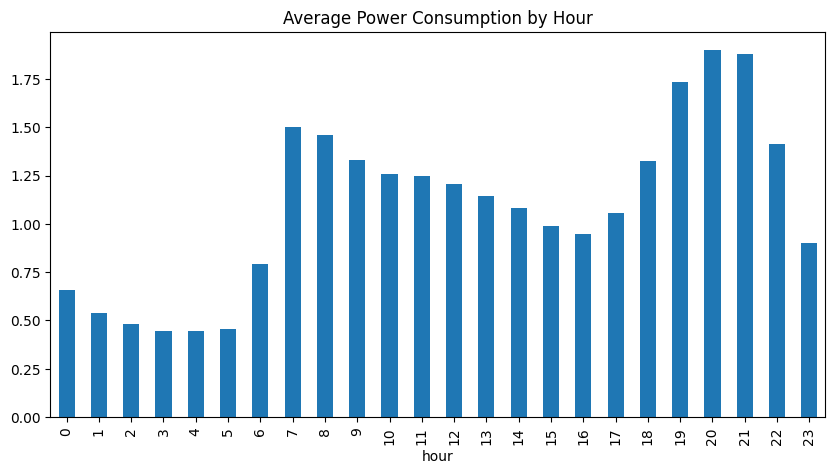

In [13]:
hourly.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Power Consumption by Hour")
plt.show()


### 2.4 曜日分析

このコードでは、日時から曜日を表す `weekday` を作成する。
月曜日が0、日曜日が6。

曜日ごとの平均電力消費量を計算します。

In [14]:
df["weekday"] = df["datetime"].dt.dayofweek

weekday_mean = (
    df.groupby("weekday")
      ["Global_active_power"]
      .mean()
)

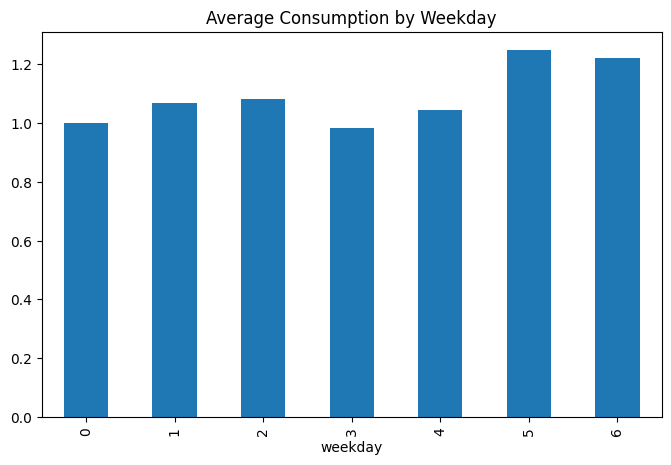

In [15]:
weekday_mean.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Consumption by Weekday")
plt.show()


---

## 3. 特徴量作成

### 3.1 時刻特徴量

予測に使う時刻特徴量として、月、日、時間、分、曜日を `datetime` から作成する。

In [16]:
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute
df["weekday"] = df["datetime"].dt.dayofweek

### 3.2 ラグ特徴量

60分前の `Global_active_power` を `lag_60` とし、24時間前の `Global_active_power` を `lag_1440` として作成する。  
ラグ特徴量を作ったことで先頭に発生した欠損値を削除。

In [17]:
df["lag_60"] = (
    df["Global_active_power"]
      .shift(60)
)

df["lag_1440"] = (
    df["Global_active_power"]
      .shift(1440)
)

df = df.dropna()

---

## 4. 学習データ

授業中に実行しやすいように、まずは20万件程度にサンプリング。  
全件で試したい場合は、次のセルにスキップしてよい。

In [18]:
sample_size = 200_000

if len(df) > sample_size:
    df = (
        df.sample(n=sample_size, random_state=42)
          .sort_values("datetime")
          .reset_index(drop=True)
    )

print(df.shape)


(200000, 17)


### 4.1 説明変数

このコードでは、LightGBM に入力する説明変数の列名を `features` として定義

In [19]:
features = [
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour",
    "weekday",
    "month",
    "lag_60",
    "lag_1440"
]


説明変数 `X` と目的変数 `y` を作成。  
ここでは `Global_active_power` を予測対象にしている。


In [20]:
X = df[features]

y = df["Global_active_power"]


### 4.2 時系列分割

ここでは、ランダム分割は使っていない。  
というのもデータには時系列の構造があり、独立なサンプルではないから。    

データの先頭80%を学習用、残り20%をテスト用に分けるようにする。

In [21]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]



---

## 5. LightGBM

### 5.1 学習

予測結果を MAE、RMSE、$R^2$ でまとめて評価する関数を定義。


In [22]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


LightGBM の回帰モデルを定義し、学習データを使ってモデルを学習する。

In [23]:
lgbm = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm.fit(X_train, y_train)


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=600,
              n_jobs=-1, random_state=42, subsample=0.8, verbose=-1)

### 5.2 予測

学習済みの LightGBM モデルを使って、テストデータに対する予測値を計算。

In [24]:
y_pred_lgbm = lgbm.predict(X_test)


---

## 6. 評価

### 6.1 評価指標

テストデータの実測値と予測値を比較し、MAE、RMSE、$R^2$ を計算する。


In [25]:
lgbm_metrics = regression_metrics(y_test, y_pred_lgbm)
lgbm_metrics


{'MAE': 0.02263390425674375,
 'RMSE': np.float64(0.033520222927189945),
 'R2': 0.9986033850600473}

（あれ、これはどういうこと？）


### 6.2 実測値 vs 予測値

実測値と予測値の散布図を描き、予測がどの程度当たっているかを確認。

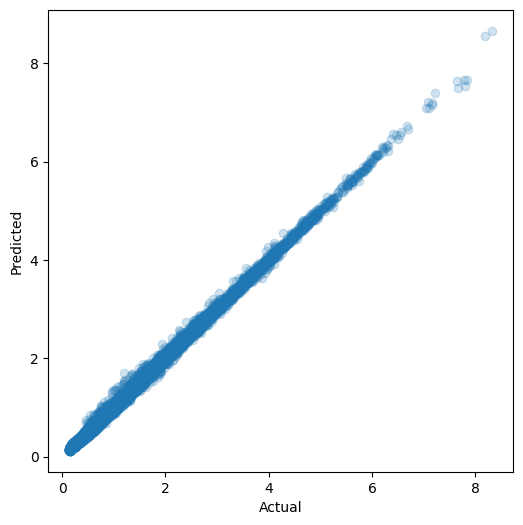

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_lgbm,
    alpha=0.2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()


（45度線に完璧に乗っている ... 完璧に予測できているということなのか ... ?）

### 6.3 特徴量重要度

LightGBM の特徴量重要度を DataFrame にまとめ、重要度が高い順に並べる。

In [27]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgbm.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)


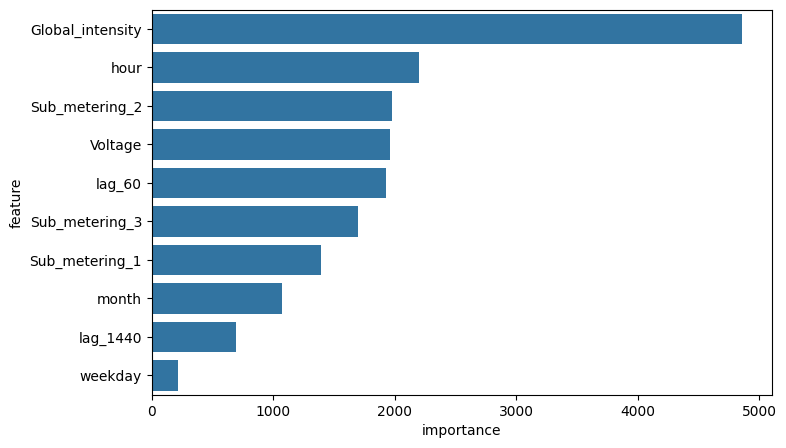

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.show()


## 7. 感想

さすがに、このウルトラ高精度な予測はおかしくないか？

'R2': 0.9986033850600473

何がおかしいのか、検証してみよう
